<a href="https://colab.research.google.com/github/yagmurogetman/DSA210-Project/blob/main/data_visulization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

df_cuisine = pd.read_csv('global_cuisines_master_final.csv')
df_temp = pd.read_csv('standardized_temperature.csv')
df_hum = pd.read_csv('standardized_humidity.csv')
df_precip = pd.read_csv('standardized_precipitation.csv')

print("Cuisine Dataset Head:")
print(df_cuisine.head())

Cuisine Dataset Head:
  Country_Code Country_Name     Dish_Name           Main_Ingredient
0          AFG  Afghanistan  Kabuli Pulao         Rice/Lamb/Carrots
1          ALB      Albania     Tavë Kosi          Lamb/Yogurt/Rice
2          DZA      Algeria      Couscous  Semolina/Vegetables/Meat
3          ARG    Argentina         Asado                 Beef/Salt
4          AUS    Australia      Meat Pie        Minced Meat/Pastry


In [23]:
# Extracting only relevant columns and renaming 'Value' to specific climate factors
df_temp = df_temp[['Country_Code', 'Value']].rename(columns={'Value': 'Temperature'})
df_hum = df_hum[['Country_Code', 'Value']].rename(columns={'Value': 'Humidity'})
df_precip = df_precip[['Country_Code', 'Value']].rename(columns={'Value': 'Precipitation'})

print("Climate data columns standardized.")

Climate data columns standardized.


In [24]:
# Merging all dataframes on 'Country_Code'
df_master = df_cuisine.merge(df_temp, on='Country_Code') \
                      .merge(df_hum, on='Country_Code') \
                      .merge(df_precip, on='Country_Code')

# Drop potential duplicate columns if they exist
df_master = df_master.loc[:,~df_master.columns.duplicated()]

print(f"Master dataset created with {len(df_master)} countries.")

Master dataset created with 66 countries.


In [25]:
# Splitting ingredients and converting them into dummy variables
ingredients_binary = df_master['Main_Ingredient'].str.get_dummies(sep='/')

# Concatenate the binary ingredient columns with the climate data
df_processed = pd.concat([df_master, ingredients_binary], axis=1)

print("Ingredients successfully tokenized into binary features.")

Ingredients successfully tokenized into binary features.


In [26]:
# Checking for null values
if df_processed.isnull().values.any():
    df_processed = df_processed.fillna(0) # Filling missing ingredient flags with 0
    print("Missing values handled.")

# Saving the final processed dataset
df_processed.to_csv('processed_culinary_climate_data.csv', index=False)
print("Processing complete. File saved as 'processed_culinary_climate_data.csv'.")

Processing complete. File saved as 'processed_culinary_climate_data.csv'.


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the processed data
df = pd.read_csv('processed_culinary_climate_data.csv')

# Verify the data
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 66 rows and 86 columns.


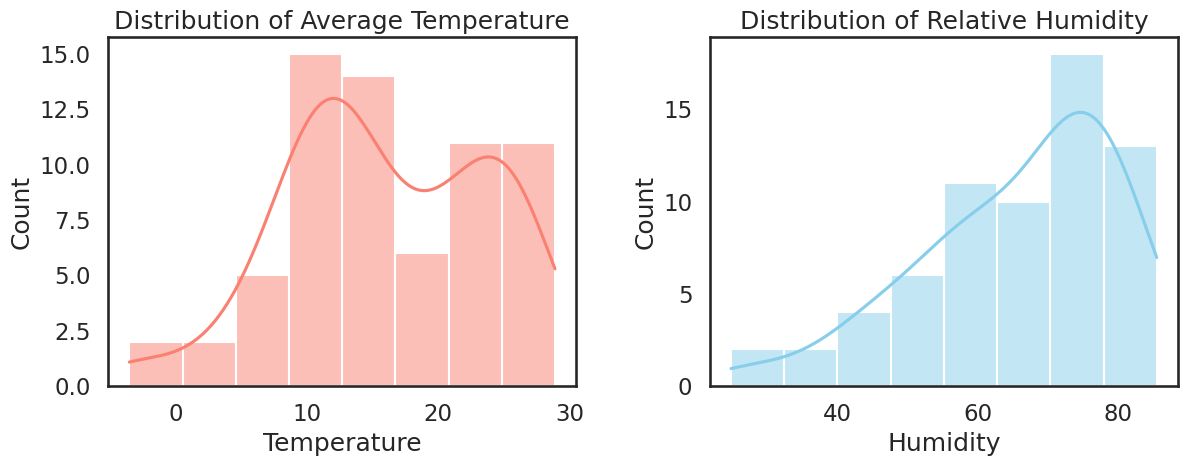

In [28]:
plt.figure(figsize=(12, 5))

# Temperature Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Temperature'], kde=True, color='salmon')
plt.title('Distribution of Average Temperature')

# Humidity Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Humidity'], kde=True, color='skyblue')
plt.title('Distribution of Relative Humidity')

plt.tight_layout()
plt.show()

In [29]:
# List of columns that represent ingredients (all columns after 'Precipitation')
ingredient_cols = df.columns[df.columns.get_loc('Precipitation') + 1:]

# Calculate correlations
correlations = df[ingredient_cols].corrwith(df['Temperature']).sort_values()

# Display top 5 cold-climate and top 5 hot-climate ingredients
print("Top 5 Cold-Climate Ingredients:\n", correlations.head(5))
print("\nTop 5 Hot-Climate Ingredients:\n", correlations.tail(5))

Top 5 Cold-Climate Ingredients:
 Cabbage        -0.347065
Cheese Curds   -0.319960
Gravy          -0.319960
Fries          -0.319960
Beets          -0.301802
dtype: float64

Top 5 Hot-Climate Ingredients:
 Rice            0.189697
Pork            0.195160
Chicken         0.197671
Wheat           0.211037
Rice Noodles    0.214627
dtype: float64


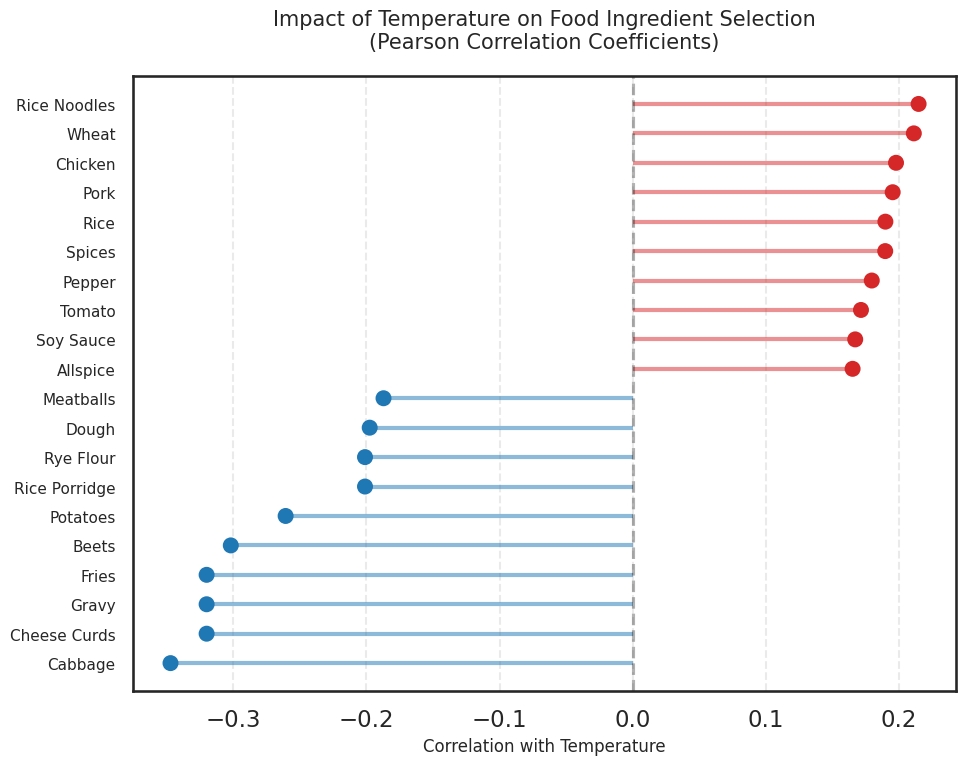

In [30]:
# Selecting top 10 and bottom 10 ingredients for a clear visual
top_ingredients = pd.concat([correlations.head(10), correlations.tail(10)])
plot_df = top_ingredients.reset_index()
plot_df.columns = ['Ingredient', 'Correlation']

# Plotting
plt.figure(figsize=(10, 8))
colors = ['#1f77b4' if x < 0 else '#d62728' for x in plot_df['Correlation']]

plt.hlines(y=plot_df.index, xmin=0, xmax=plot_df['Correlation'], color=colors, alpha=0.5, linewidth=3)
plt.scatter(plot_df['Correlation'], plot_df.index, color=colors, s=100)

plt.yticks(plot_df.index, plot_df['Ingredient'], fontsize=11)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Impact of Temperature on Food Ingredient Selection\n(Pearson Correlation Coefficients)', fontsize=15, pad=20)
plt.xlabel('Correlation with Temperature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

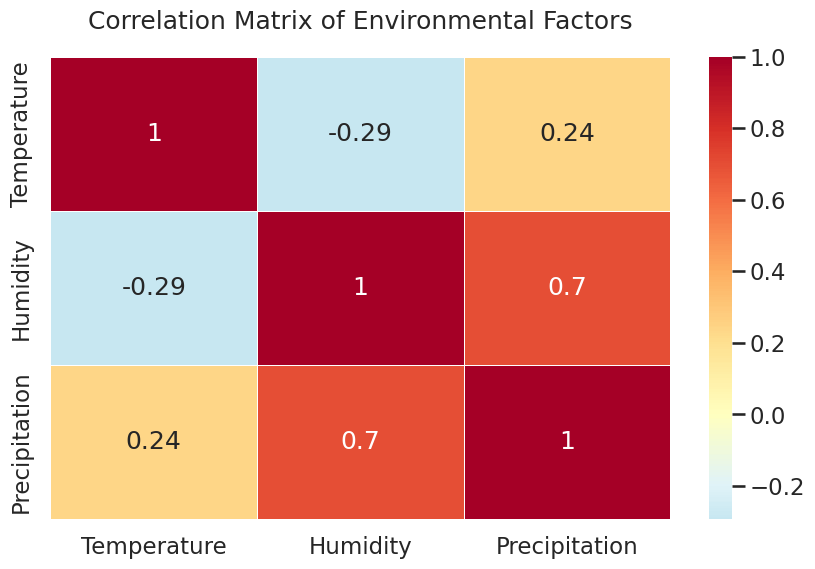

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting a professional aesthetic
sns.set_context("talk")
sns.set_style("white")

plt.figure(figsize=(10, 6))
# Focus on the correlation between climate variables
climate_corr = df[['Temperature', 'Humidity', 'Precipitation']].corr()

sns.heatmap(climate_corr, annot=True, cmap='RdYlBu_r', center=0, linewidths=.5)
plt.title('Correlation Matrix of Environmental Factors', fontsize=18, pad=20)
plt.show()

/tmp/ipykernel_26543/3521402417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_freq.values, y=top_freq.index, palette="viridis")


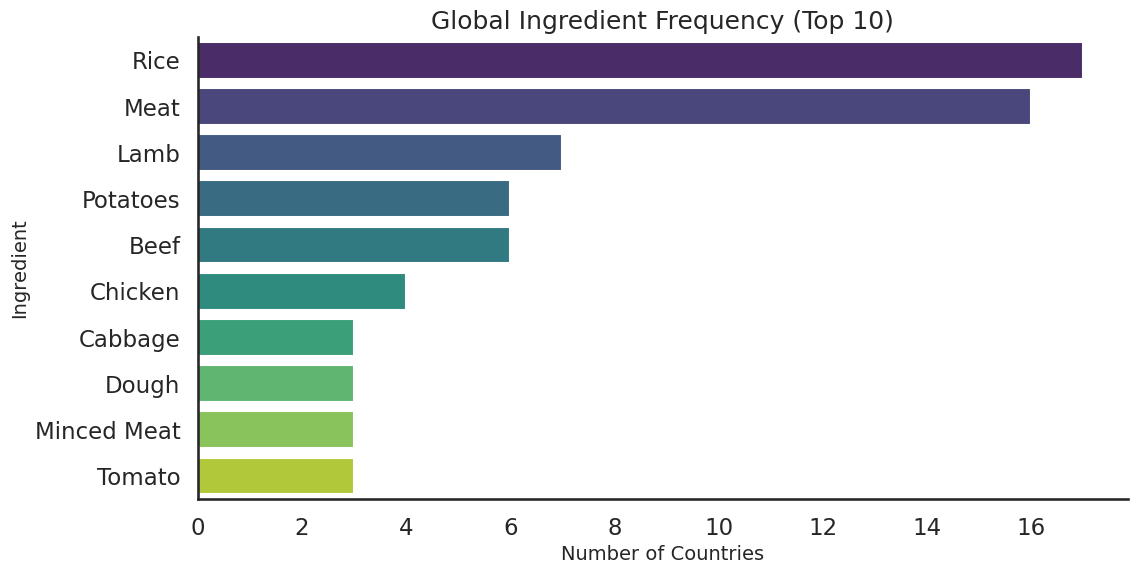

In [32]:
# Calculating the frequency of top ingredients
top_freq = ingredients_binary.sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_freq.values, y=top_freq.index, palette="viridis")
plt.title('Global Ingredient Frequency (Top 10)', fontsize=18)
plt.xlabel('Number of Countries', fontsize=14)
plt.ylabel('Ingredient', fontsize=14)
sns.despine() # Removes the top and right borders for a cleaner look
plt.show()

/tmp/ipykernel_26543/3029048341.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=subset['Temperature'], y=subset['Humidity'], label=ing, shade=True, alpha=0.3)
/tmp/ipykernel_26543/3029048341.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=subset['Temperature'], y=subset['Humidity'], label=ing, shade=True, alpha=0.3)
/tmp/ipykernel_26543/3029048341.py:8: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=subset['Temperature'], y=subset['Humidity'], label=ing, shade=True, alpha=0.3)
/tmp/ipykernel_26543/3029048341.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14

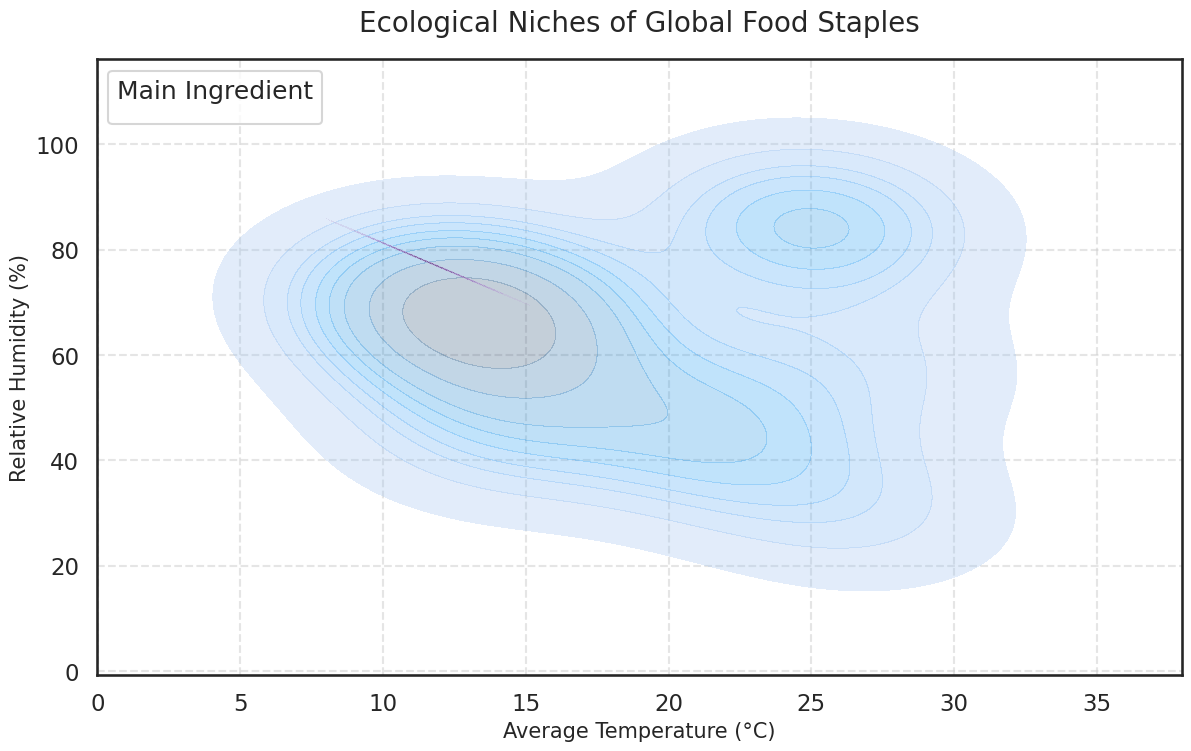

In [33]:
# We pick representative ingredients
representatives = ['Rice', 'Potato', 'Corn', 'Wheat', 'Fish']

plt.figure(figsize=(14, 8))

for ing in representatives:
    subset = df[df[ing] == 1]
    sns.kdeplot(x=subset['Temperature'], y=subset['Humidity'], label=ing, shade=True, alpha=0.3)

plt.title('Ecological Niches of Global Food Staples', fontsize=20, pad=20)
plt.xlabel('Average Temperature (°C)', fontsize=15)
plt.ylabel('Relative Humidity (%)', fontsize=15)
plt.legend(title='Main Ingredient', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

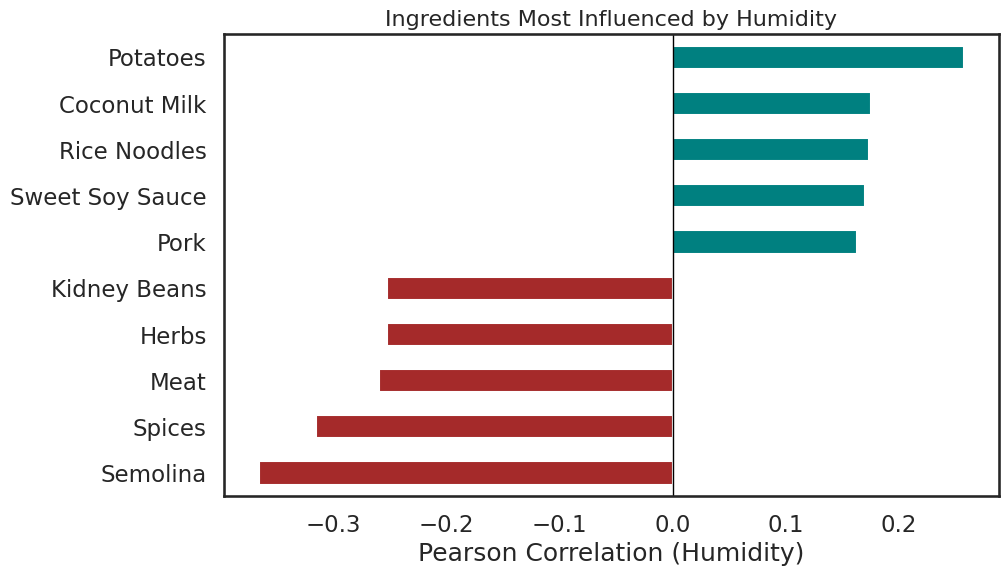

In [34]:
# Calculate correlation with Humidity
hum_correlations = ingredients_binary.corrwith(df['Humidity']).sort_values()
top_hum = pd.concat([hum_correlations.head(5), hum_correlations.tail(5)])

plt.figure(figsize=(10, 6))
top_hum.plot(kind='barh', color=(top_hum > 0).map({True: 'teal', False: 'brown'}))
plt.title('Ingredients Most Influenced by Humidity', fontsize=16)
plt.xlabel('Pearson Correlation (Humidity)')
plt.axvline(0, color='black', lw=1)
plt.show()

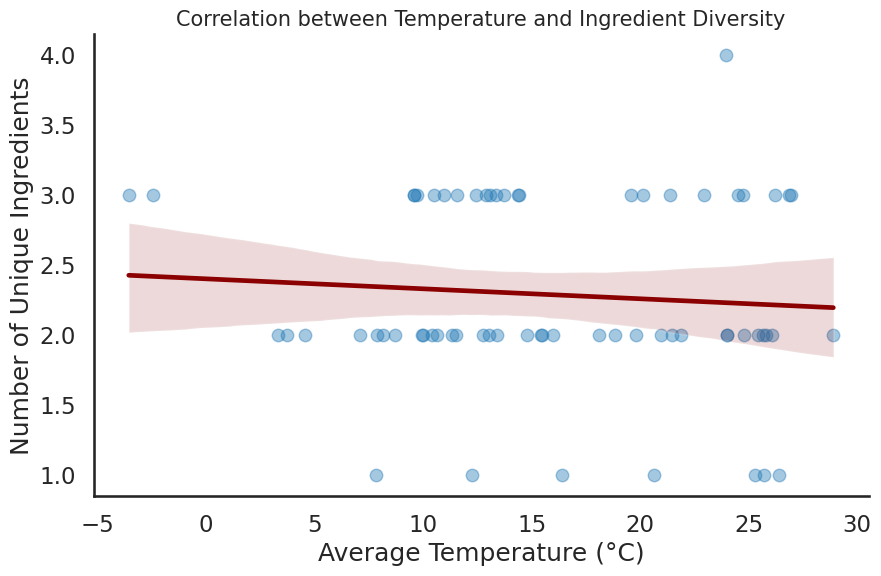

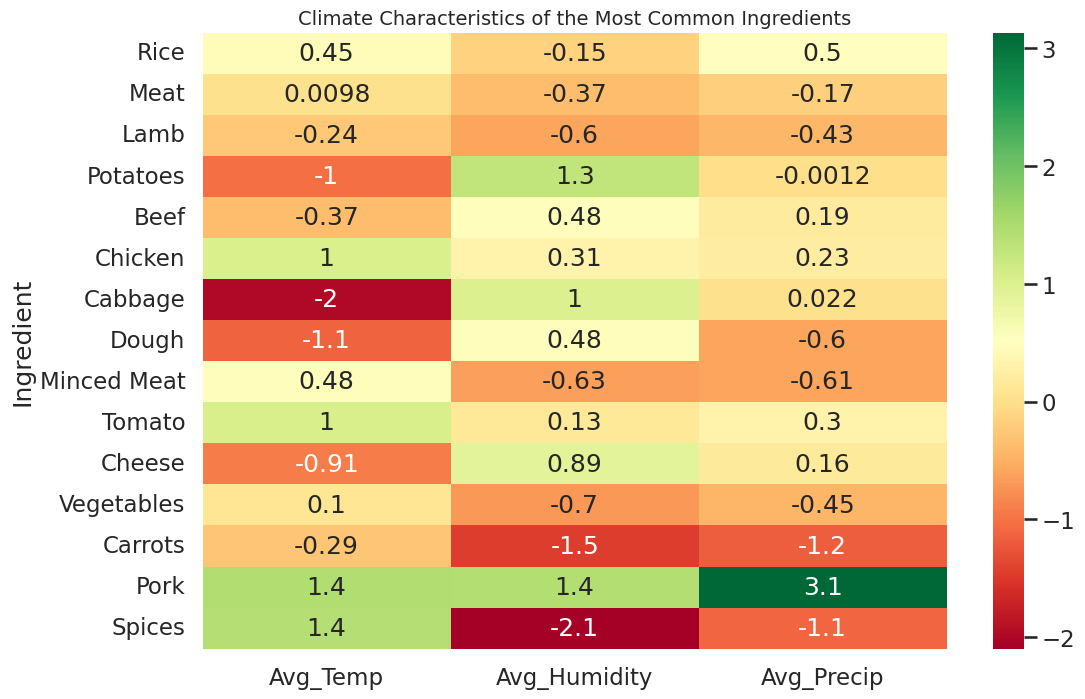

/tmp/ipykernel_26543/1650204473.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_analysis = df_processed.groupby('Climate_Zone')[available_staples].mean()


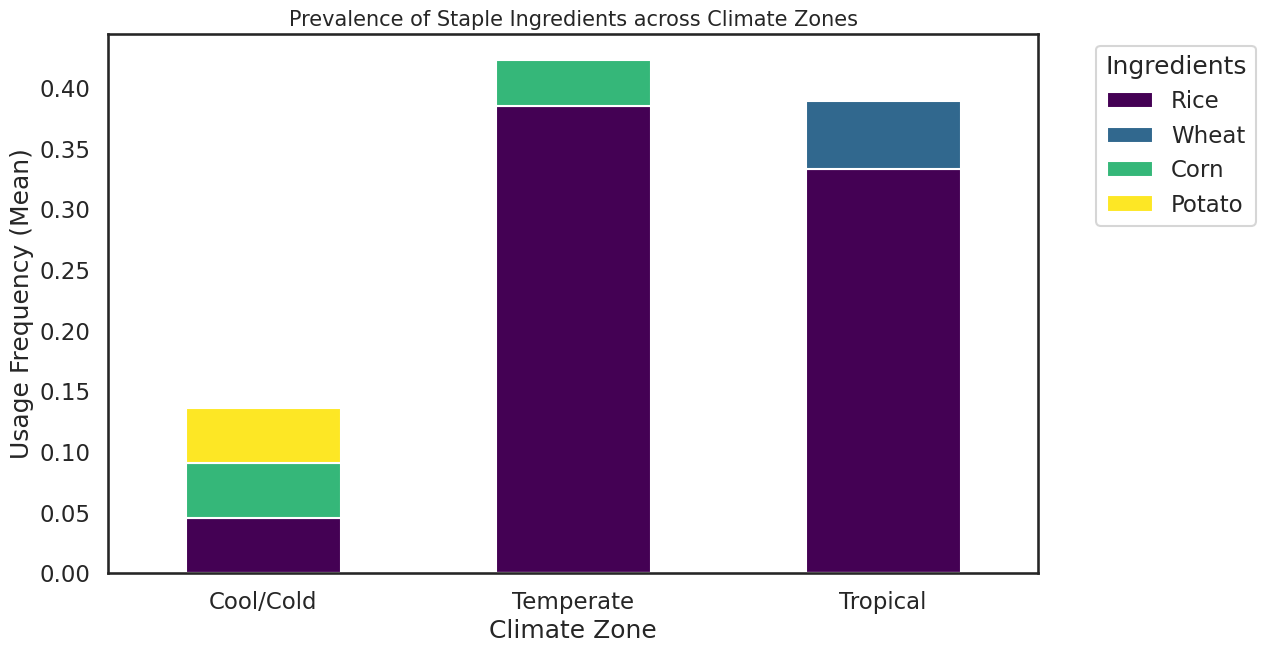

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Visualization 1: Ingredient Diversity vs. Temperature ---
# This proves if warmer climates lead to more complex ingredient use
df_processed['Ingredient_Diversity'] = df_processed['Main_Ingredient'].apply(lambda x: len(str(x).split('/')))

plt.figure(figsize=(10, 6))
sns.regplot(data=df_processed, x='Temperature', y='Ingredient_Diversity',
            scatter_kws={'alpha':0.4}, line_kws={'color':'darkred'})

plt.title('Correlation between Temperature and Ingredient Diversity', fontsize=15)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Number of Unique Ingredients')
sns.despine()
plt.show()

# --- Visualization 2: Climate Profile of Top 15 Ingredients ---
# Shows which ingredients thrive in specific Temperature/Humidity/Precipitation
top_15_ingredients = ingredients_binary.sum().sort_values(ascending=False).head(15).index

climate_profile = []
for ing in top_15_ingredients:
    subset = df_processed[df_processed[ing] == 1]
    climate_profile.append({
        'Ingredient': ing,
        'Avg_Temp': subset['Temperature'].mean(),
        'Avg_Humidity': subset['Humidity'].mean(),
        'Avg_Precip': subset['Precipitation'].mean()
    })

df_profile = pd.DataFrame(climate_profile).set_index('Ingredient')

plt.figure(figsize=(12, 8))
# Standardizing data (Z-score) to compare different units (Temp vs Humidity)
sns.heatmap(df_profile.apply(lambda x: (x-x.mean())/x.std()), annot=True, cmap='RdYlGn')
plt.title('Climate Characteristics of the Most Common Ingredients', fontsize=14)
plt.show()

# --- Visualization 3: Ingredient Prevalence by Climate Zone ---
# Categorizing countries into zones to see staple food shifts
df_processed['Climate_Zone'] = pd.cut(df_processed['Temperature'],
                                     bins=[-float('inf'), 12, 22, float('inf')],
                                     labels=['Cool/Cold', 'Temperate', 'Tropical'])

# Update this list with the actual column names from your ingredients_binary
staple_list = ['Rice', 'Wheat', 'Corn', 'Potato', 'Garlic']
# Filter list to only include columns that actually exist in your data
available_staples = [ing for ing in staple_list if ing in df_processed.columns]

zone_analysis = df_processed.groupby('Climate_Zone')[available_staples].mean()

zone_analysis.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Prevalence of Staple Ingredients across Climate Zones', fontsize=15)
plt.ylabel('Usage Frequency (Mean)')
plt.xlabel('Climate Zone')
plt.legend(title='Ingredients', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()